# Rossmann Sales — Red Neuronal con Entradas Heterogeneas
**Persona:** Oscar  |  **Equipo:** Oscar - Dani - Fernando

Arquitectura many-to-one: LSTM (serie temporal) + rama densa (embeddings estaticos + temporales).
Target: log1p(Sales) normalizado por tienda. Tiendas objetivo: [1, 2, 3, 4, 5, 562, 682, 733, 769].

> Los Apendices al final contienen EDA detallado, arquitecturas completas, curvas de entrenamiento y visualizacion de embeddings.

## 0 . Setup

In [35]:
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as L
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from scipy.stats import linregress
warnings.filterwarnings("ignore")

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path: sys.path.insert(0, PROJECT_ROOT)

import src.preprocessing as prep
import src.evaluate      as ev

DATA_DIR    = os.path.join(PROJECT_ROOT, "data")
OUTPUTS_DIR = os.path.join(PROJECT_ROOT, "outputs")
os.makedirs(OUTPUTS_DIR, exist_ok=True)

SEQ_LEN = 30
train_raw, store_raw = prep.load_raw_data(DATA_DIR)
print(f"TF {tf.__version__} | train {train_raw.shape} | store {store_raw.shape}")

TF 2.21.0 | train (1001599, 10) | store (1115, 10)


## 1 . EDA

,dias,media,std,cv_%,StoreType,Assortment,Promo2,CompetitionDistance
Store,,,,,,,,
1,769,4763.0,1015.0,21.3,c,a,0,1270.0
2,772,4956.0,1615.0,32.6,a,a,1,570.0
3,767,6950.0,2199.0,31.6,a,a,1,14130.0
4,772,9633.0,1939.0,20.1,c,c,0,620.0
5,767,4682.0,1769.0,37.8,a,a,0,29910.0
562,928,17980.0,2933.0,16.3,b,c,0,1210.0
682,928,11218.0,3262.0,29.1,b,a,0,150.0
733,928,14944.0,1842.0,12.3,b,b,0,860.0
769,928,10817.0,1859.0,17.2,b,b,1,840.0


Utiles: 830,918 (83.0%) | Promo uplift: +22% | T562/T1: 3.8x


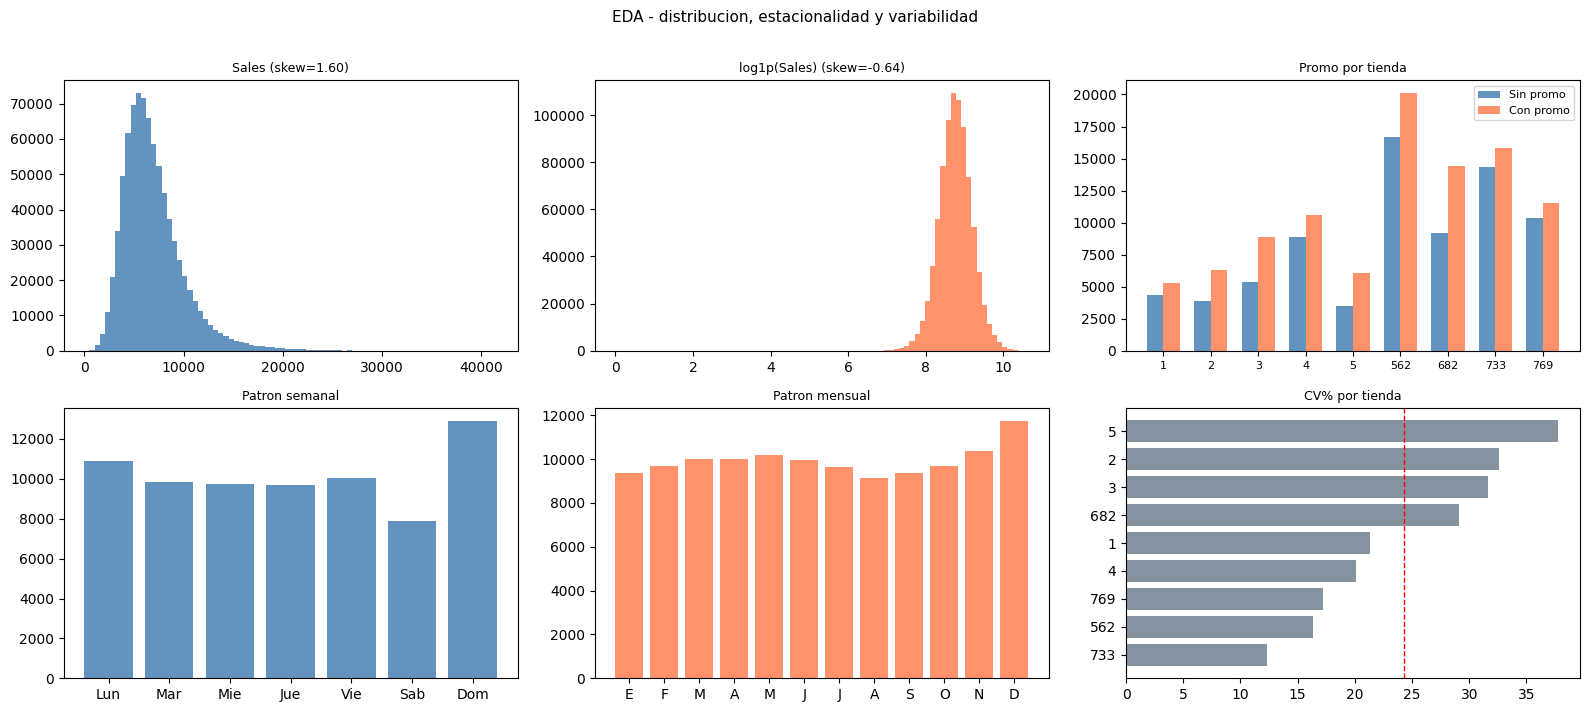

Ver Apendice A para series temporales mensuales por tienda.


In [36]:
# Carga + estadisticas de las 9 tiendas objetivo
train_raw, store_raw = prep.load_raw_data(DATA_DIR)
n = len(train_raw)
n_closed    = (train_raw["Open"]==0).sum()
n_zero_open = ((train_raw["Open"]==1) & (train_raw["Sales"]==0)).sum()

tgt = train_raw[train_raw["Store"].isin(ev.TARGET_STORES) & (train_raw["Open"]==1)]
stats = tgt.groupby("Store")["Sales"].agg(dias="count", media="mean", std="std").round(0)
stats["cv_%"] = (stats["std"]/stats["media"]*100).round(1)
meta = store_raw[store_raw["Store"].isin(ev.TARGET_STORES)].set_index("Store")
stats = stats.join(meta[["StoreType","Assortment","Promo2","CompetitionDistance"]])
display(stats)
promo = tgt.groupby("Promo")["Sales"].mean()
print(f"Utiles: {n-n_closed-n_zero_open:,} ({(n-n_closed-n_zero_open)/n:.1%}) | Promo uplift: +{promo[1]/promo[0]-1:.0%} | T562/T1: {stats.loc[562,'media']/stats.loc[1,'media']:.1f}x")

sales = train_raw.loc[train_raw["Open"]==1, "Sales"]
log_s = np.log1p(sales)
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
axes[0,0].hist(sales, bins=80, color="steelblue", alpha=.85, edgecolor="none")
axes[0,0].set_title(f"Sales (skew={sales.skew():.2f})", fontsize=9)
axes[0,1].hist(log_s, bins=80, color="coral", alpha=.85, edgecolor="none")
axes[0,1].set_title(f"log1p(Sales) (skew={log_s.skew():.2f})", fontsize=9)
promo_store = tgt.groupby(["Store","Promo"])["Sales"].mean().unstack()
x = np.arange(len(promo_store)); w=.35
axes[0,2].bar(x-w/2, promo_store[0], w, label="Sin promo", color="steelblue", alpha=.85)
axes[0,2].bar(x+w/2, promo_store[1], w, label="Con promo", color="coral", alpha=.85)
axes[0,2].set_xticks(x); axes[0,2].set_xticklabels(promo_store.index, fontsize=8)
axes[0,2].set_title("Promo por tienda", fontsize=9); axes[0,2].legend(fontsize=8)
by_day = tgt.groupby("DayOfWeek")["Sales"].mean()
axes[1,0].bar(range(7), by_day.values, color="steelblue", alpha=.85)
axes[1,0].set_xticks(range(7)); axes[1,0].set_xticklabels(["Lun","Mar","Mie","Jue","Vie","Sab","Dom"])
axes[1,0].set_title("Patron semanal", fontsize=9)
by_month = tgt.assign(mes=tgt["Date"].dt.month).groupby("mes")["Sales"].mean()
axes[1,1].bar(range(12), by_month.values, color="coral", alpha=.85)
axes[1,1].set_xticks(range(12)); axes[1,1].set_xticklabels(["E","F","M","A","M","J","J","A","S","O","N","D"])
axes[1,1].set_title("Patron mensual", fontsize=9)
cv = (tgt.groupby("Store")["Sales"].std()/tgt.groupby("Store")["Sales"].mean()*100).sort_values()
axes[1,2].barh(cv.index.astype(str), cv.values, color="slategray", alpha=.85)
axes[1,2].axvline(cv.mean(), color="red", lw=1, ls="--")
axes[1,2].set_title("CV% por tienda", fontsize=9)
plt.suptitle("EDA - distribucion, estacionalidad y variabilidad", fontsize=11, y=1.01)
plt.tight_layout(); plt.show()
print("Ver Apendice A para series temporales mensuales por tienda.")

### Conclusiones del EDA

#### Datos
- train.csv sin nulos. store.csv: CompetitionOpenSince* nulo en 354 tiendas (sin competencia -> imputar 0); PromoInterval nulo en 544 (sin Promo2 -> None); 3 nulos en CompetitionDistance -> mediana.
- clean_train descarta el **17 %** (170.627 dias cerrados) + 54 anomalias -> **830.918 filas utiles**.

#### Target
- Sales tiene skew **1.60**. log1p lo reduce a ~0.36. Z-score por tienda imprescindible: T562 vende 3.8x mas que T1.

#### Features mas relevantes

| Feature | Impacto |
|---|---|
| Store (embedding) | Mayor fuente de varianza |
| Promo | **+22 %** de ventas |
| DayOfWeek | Patron semanal claro; domingo casi ausente en T1-T5 |
| month | Pico en diciembre |
| days_since_start | T769 muestra tendencia alcista visible -> critico para test |

#### Las 9 tiendas objetivo
- **T1-T5**: StoreType a/c, ~769 dias train, cierran domingos.
- **T562/682/733/769**: StoreType b, 928 dias train (20 % mas), abren 7 dias.
- **T682**: competencia a solo 150 m. **T733**: CV%=12.3 % (mas predecible en EDA, pero falla en test).
- SEQ_LEN=30 cubre ~6 semanas de patrones semanales y quincenales.

## 2 . Preprocesado

In [37]:
# Helper: features del dia objetivo (inspirado en NB03 del profesor)
def extract_target_day_features(df, seq_len=SEQ_LEN):
    dow_parts, month_parts = [], []
    for _, grp in df.groupby("Store"):
        grp = grp.sort_values("Date")
        if len(grp) <= seq_len: continue
        dow_parts.append((grp["DayOfWeek"].iloc[seq_len:].values - 1).astype(np.int32)[:, None])
        month_parts.append((grp["Date"].dt.month.iloc[seq_len:].values - 1).astype(np.int32)[:, None])
    return np.concatenate(dow_parts), np.concatenate(month_parts)

# Pipeline completo
df = prep.clean_train(train_raw)
df = prep.merge_store_features(df, store_raw)
df, cat_encoders = prep.encode_categoricals(df)
df = prep.engineer_features(df)
df_train, df_val, df_test = prep.temporal_split(df)
store_stats = prep.build_store_normalizer(df_train)
df_train = prep.normalize_sales(df_train, store_stats)
df_val   = prep.normalize_sales(df_val,   store_stats)
df_test  = prep.normalize_sales(df_test,  store_stats)
X_seq_tr, X_static_tr, y_tr = prep.build_sequences(df_train, SEQ_LEN)
X_seq_va, X_static_va, y_va = prep.build_sequences(df_val,   SEQ_LEN)
X_seq_te, X_static_te, y_te = prep.build_sequences(df_test,  SEQ_LEN)
dow_tr, month_tr = extract_target_day_features(df_train)
dow_va, month_va = extract_target_day_features(df_val)
dow_te, month_te = extract_target_day_features(df_test)
print(f"Train: {X_seq_tr.shape} | Val: {X_seq_va.shape} | Test: {X_seq_te.shape}")
print(f"Static: {X_static_tr.shape} | dow: {dow_tr.shape}")
print(f"Splits: train hasta {ev.SPLIT_TRAIN_END.date()} | val {ev.SPLIT_VAL_START.date()}->{ev.SPLIT_VAL_END.date()} | test {ev.SPLIT_TEST_START.date()}->2015-07-17")

Train: (544077, 30, 11) | Val: (42732, 30, 11) | Test: (149159, 30, 11)
Static: (544077, 8) | dow: (544077, 1)
Splits: train hasta 2014-09-30 | val 2014-10-01->2014-12-31 | test 2015-01-01->2015-07-17


### Decisiones de diseno

| Decision | Justificacion |
|---|---|
| log1p(Sales) + z-score por tienda | Skew 1.60->0.36; T562 vende 3.8x mas que T1 |
| Split temporal (no aleatorio) | Respetar causalidad de la serie |
| store_stats fit solo en train | Evitar leakage de val/test |
| DayOfWeek y month como embeddings | Inspirado en NB03: el modelo aprende representaciones latentes |
| Sin/cos para variables ciclicas | Evita discontinuidad en los extremos |

**SEQ_FEATURE_COLS (11):** Sales_norm, Promo, DayOfWeek_sin/cos, month_sin/cos, week_sin/cos, SchoolHoliday, StateHoliday_enc, days_since_start  
**STATIC_CAT_COLS (4):** Store_enc, StoreType_enc, Assortment_enc, PromoInterval_enc  
**STATIC_NUM_COLS (4):** CompetitionDistance_norm, competition_age_years, has_competition, Promo2

## 3 . Modelo base

In [38]:
# Arquitectura many-to-one con entradas heterogeneas (ver Apendice B para model.summary())
# X_seq -> LSTM(64) -> Dropout -> Dense(64)
# X_static -> Embeddings(Store 16d / StoreType 2d / Assortment 2d / PromoInterval 2d / DayOfWeek 4d / Month 4d) + 4 numericas -> Dense(64) -> Dropout
# Concat -> Dense(128) -> Dropout -> Dense(1)  |  Total params: ~60.435

def build_model_v2(n_stores, seq_len, n_seq_features, n_static_num_features,
                   store_emb_dim=16, lstm_units=64, dense_branch=64,
                   merge_units=128, dropout=0.2, recurrent_dropout=0.0):
    n_cat = len(prep.STATIC_CAT_COLS)
    inp_seq    = keras.Input((seq_len, n_seq_features),        name="seq")
    inp_static = keras.Input((n_cat + n_static_num_features,), name="static")
    inp_dow    = keras.Input((1,), dtype="int32",               name="dow")
    inp_month  = keras.Input((1,), dtype="int32",               name="month")
    x = L.LSTM(lstm_units, recurrent_dropout=recurrent_dropout, name="lstm")(inp_seq)
    x = L.Dropout(dropout)(x)
    x = L.Dense(dense_branch, activation="relu")(x)
    cat_specs = [(0,n_stores,store_emb_dim,"emb_Store"),(1,4,2,"emb_StoreType"),
                 (2,3,2,"emb_Assortment"),(3,4,2,"emb_PromoInterval")]
    emb_outs = [L.Flatten()(L.Embedding(v,d,name=nm)(
                    L.Lambda(lambda t,i=i: tf.cast(t[:,i:i+1],tf.int32))(inp_static)))
                for i,v,d,nm in cat_specs]
    emb_dow   = L.Flatten()(L.Embedding(7,  4, name="emb_dow")(inp_dow))
    emb_month = L.Flatten()(L.Embedding(12, 4, name="emb_month")(inp_month))
    num_feats = L.Lambda(lambda t: t[:, n_cat:])(inp_static)
    s = L.Concatenate()(emb_outs + [emb_dow, emb_month, num_feats])
    s = L.Dense(dense_branch, activation="relu")(s)
    s = L.Dropout(dropout)(s)
    merged = L.Concatenate()([x, s])
    merged = L.Dense(merge_units, activation="relu")(merged)
    merged = L.Dropout(dropout)(merged)
    out = L.Dense(1, activation="linear", name="output")(merged)
    model = keras.Model(inputs=[inp_seq, inp_static, inp_dow, inp_month], outputs=out)
    model.compile(optimizer="adam", loss="mse")
    return model

def make_callbacks(name, patience_reduce=5):
    return [
        keras.callbacks.ModelCheckpoint(
            os.path.join(OUTPUTS_DIR, f"{name}.weights.h5"),
            monitor="val_loss", save_best_only=True, save_weights_only=True),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=patience_reduce, min_lr=1e-6),
    ]

model = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS),
)
print(f"Total params: {model.count_params():,}")

Total params: 60,435


In [39]:
history = model.fit(
    [X_seq_tr, X_static_tr, dow_tr, month_tr], y_tr,
    validation_data=([X_seq_va, X_static_va, dow_va, month_va], y_va),
    epochs=10, batch_size=256, callbacks=make_callbacks("baseline"), verbose=1,
)
model.load_weights(os.path.join(OUTPUTS_DIR, "baseline.weights.h5"))
y_pred_base = model.predict([X_seq_te, X_static_te, dow_te, month_te], verbose=0).flatten()
report = ev.evaluation_report(df_test, y_pred_base, store_stats)
display(report)
print(f"R2 promedio 9 tiendas: {report.iloc[:-1]['R2'].mean():.4f}")

Epoch 1/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 220s 96ms/step - loss: 0.4323 - val_loss: 0.8083 - learning_rate: 0.0010
Epoch 2/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 153s 72ms/step - loss: 0.2604 - val_loss: 0.8480 - learning_rate: 0.0010
Epoch 3/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 178s 84ms/step - loss: 0.2319 - val_loss: 0.8379 - learning_rate: 0.0010
Epoch 4/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 173s 81ms/step - loss: 0.2177 - val_loss: 0.8290 - learning_rate: 0.0010
Epoch 5/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 228s 93ms/step - loss: 0.2072 - val_loss: 0.8930 - learning_rate: 0.0010
Epoch 6/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 179s 84ms/step - loss: 0.1994 - val_loss: 0.8485 - learning_rate: 0.0010
Epoch 7/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 183s 75ms/step - loss: 0.1879 - val_loss: 0.7782 - learning_rate: 5.0000e-04
Epoch 8/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 204s 76ms/step - loss: 0.1841 - val_loss: 0.7978 - learning_rate: 5.0000e-04
Epoch 9/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 226s 87ms/step - loss: 0.1821 

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.618972,4502.699248,4707.243652
1,2,134,0.758137,4981.388060,5039.337891
2,3,133,0.838175,6973.142857,7065.030273
3,4,134,0.582276,9863.313433,9844.452148
4,5,134,0.901425,4634.552239,4692.378418
5,562,168,0.692134,18096.273810,18226.072266
6,682,168,0.769535,11670.517857,11288.914062
7,733,168,0.452156,15514.529762,15207.372070
8,769,168,-0.259483,12410.410714,11269.172852
9,GLOBAL,1340,0.944999,10319.938806,10145.892578


R2 promedio 9 tiendas: 0.5948


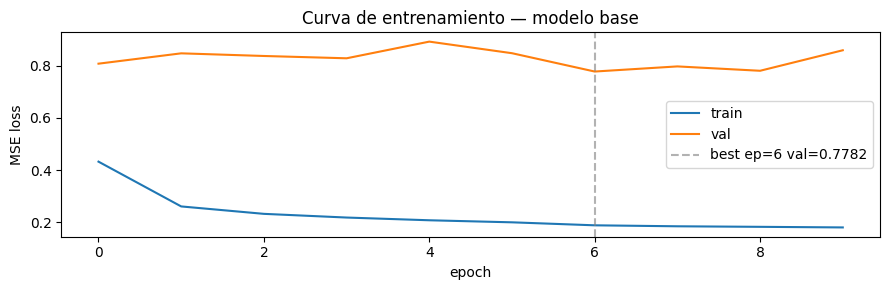

In [40]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(history.history["loss"],     label="train")
ax.plot(history.history["val_loss"], label="val")
best_val = min(history.history["val_loss"])
best_ep  = history.history["val_loss"].index(best_val)
ax.axvline(best_ep, color="gray", linestyle="--", alpha=0.6, label=f"best ep={best_ep} val={best_val:.4f}")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE loss")
ax.legend(); ax.set_title("Curva de entrenamiento — modelo base")
plt.tight_layout(); plt.show()

### Resultados del modelo base (test 2015-01-01 -> 2015-07-17)

| Tienda | R2 | Nivel | Nota |
|---|---|---|---|
| 5 | **0.901** | Excelente | Menor escala |
| 3 | 0.838 | Bien | |
| 682 | 0.770 | Bien | Competencia a 150 m |
| 2 | 0.758 | Bien | Promo2 activa |
| 562 | 0.692 | Aceptable | Mayor escala ~18k/dia |
| 1 | 0.619 | Aceptable | |
| 4 | 0.582 | Aceptable | |
| 733 | 0.452 | Pobre | CV%=12.3% pero R2 mediocre; causa sin identificar |
| **769** | **-0.260** | **Fallo** | Tendencia alcista no capturada, subestima sistematicamente |
| **Media** | **0.595** | | |

*Checkpoint en epoch 7 (val_loss=0.778, mejor de 10). Overfitting severo: train 0.18 vs val 0.78.*

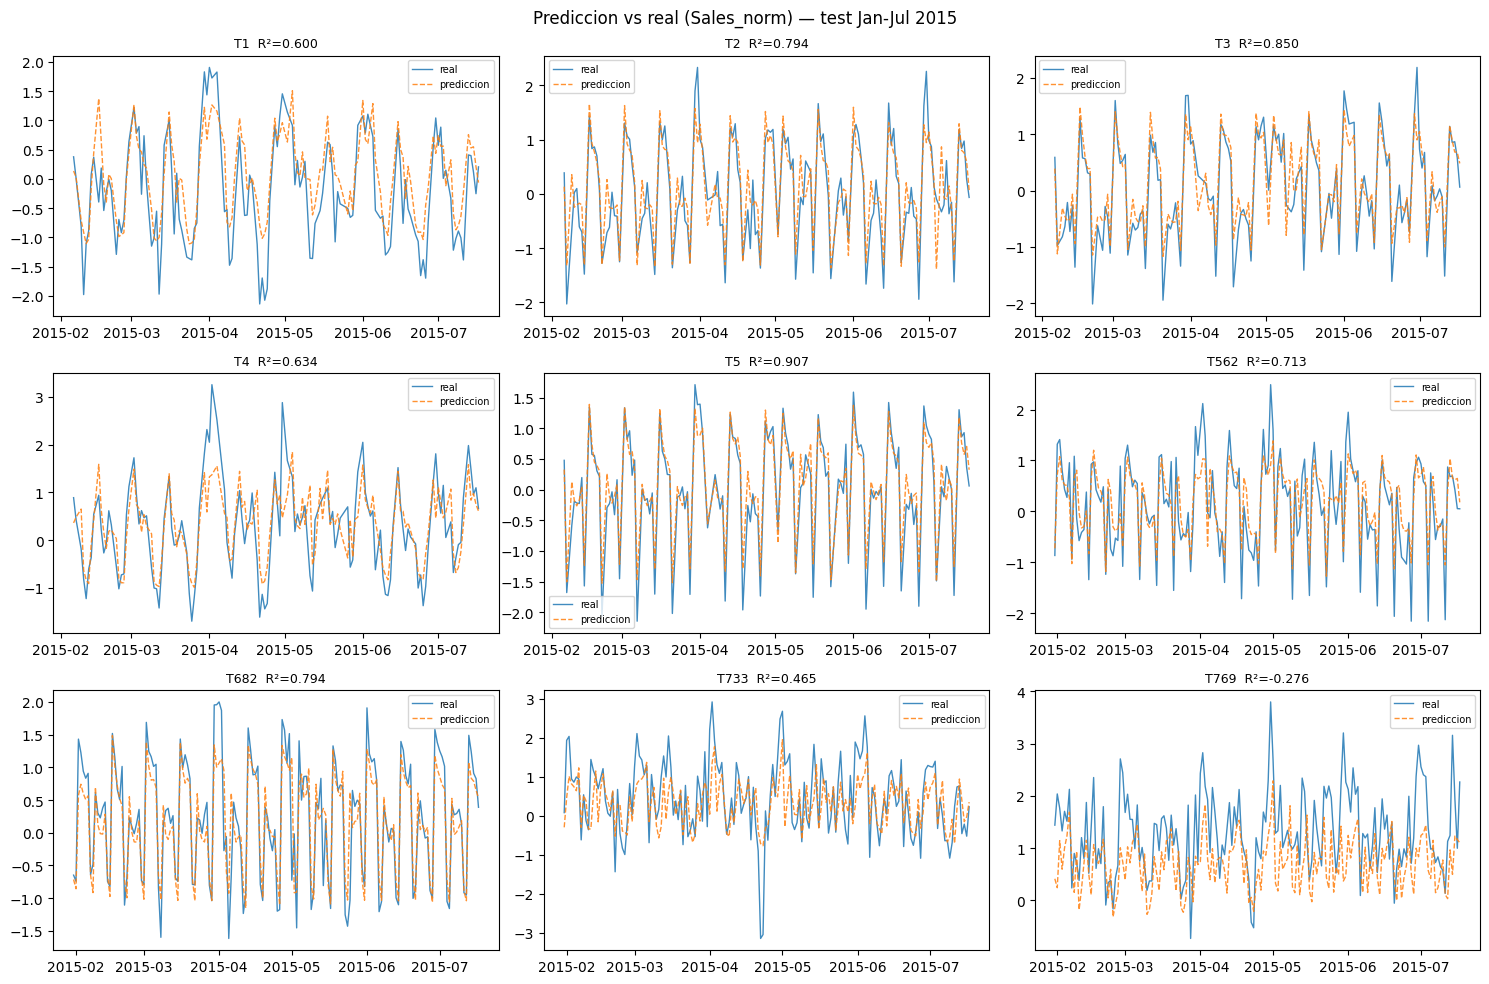

In [41]:
# Reconstruir predicciones alineadas con fechas por tienda
# groupby("Store") produce el mismo orden que build_sequences -> alineacion correcta
cursor = 0
preds_by_store = {}
for sid, grp in df_test.groupby("Store"):
    grp = grp.sort_values("Date")
    n = max(0, len(grp) - SEQ_LEN)
    preds_by_store[int(sid)] = (
        grp.iloc[SEQ_LEN:]["Date"].values,
        y_pred_base[cursor:cursor + n],
        grp.iloc[SEQ_LEN:]["Sales_norm"].values,
    )
    cursor += n

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, sid in enumerate(ev.TARGET_STORES):
    ax = axes[i]
    dates, pred, real = preds_by_store[sid]
    ax.plot(dates, real, label="real",       alpha=0.85, linewidth=1)
    ax.plot(dates, pred, label="prediccion", alpha=0.85, linewidth=1, linestyle="--")
    ax.set_title(f"T{sid}  R²={r2_score(real, pred):.3f}", fontsize=9)
    ax.legend(fontsize=7)
plt.suptitle("Prediccion vs real (Sales_norm) — test Jan-Jul 2015", fontsize=12)
plt.tight_layout()
plt.show()

## 4 . Tanda 1 — Experimentos de diagnostico (5 epochs cada uno)

Cada experimento aisla UNA variable respecto al modelo base.
Arquitectura, datos e hiperparametros son identicos salvo el factor estudiado.
Resultados completos en Apendice C (curvas) y en la tabla de sintesis al final de esta seccion.

### Exp 1 — Regularizacion L2 (l2=1e-3)

In [46]:
model_e1 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS),
    dropout=0.3,
)
_reg = keras.regularizers.L2(1e-3)
_kernels = [l.kernel for l in model_e1.layers if hasattr(l, "kernel") and l.kernel is not None]
def _loss_l2(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred)) + tf.add_n([_reg(k) for k in _kernels])
model_e1.compile(optimizer="adam", loss=_loss_l2)
h_e1 = model_e1.fit(
    [X_seq_tr, X_static_tr, dow_tr, month_tr], y_tr,
    validation_data=([X_seq_va, X_static_va, dow_va, month_va], y_va),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp1_l2"), verbose=1,
)
model_e1.load_weights(os.path.join(OUTPUTS_DIR, "exp1_l2.weights.h5"))
y_pred_e1 = model_e1.predict([X_seq_te, X_static_te, dow_te, month_te], verbose=0).flatten()
rep_e1 = ev.evaluation_report(df_test, y_pred_e1, store_stats)
display(rep_e1)


Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 133s 58ms/step - loss: 0.5292 - val_loss: 0.7550 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 125s 59ms/step - loss: 0.3160 - val_loss: 0.7686 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 126s 59ms/step - loss: 0.2872 - val_loss: 0.8177 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 119s 56ms/step - loss: 0.2746 - val_loss: 0.8478 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 129s 61ms/step - loss: 0.2670 - val_loss: 0.7507 - learning_rate: 0.0010
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.5290        4502.6992        4716.2588
     2        134  0.6949        4981.3881        5038.3306
     3        133  0.7550        6973.1429        7062.4902
     4        134  0.5757        9863.3134        9711.1396
     5        134  0.8658        4634.5522        4641.8032
   562        168  0.6632       18096.2738       18193.7363
   682    

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.529001,4502.699248,4716.258789
1,2,134,0.694939,4981.388060,5038.330566
2,3,133,0.754999,6973.142857,7062.490234
3,4,134,0.575742,9863.313433,9711.139648
4,5,134,0.865776,4634.552239,4641.803223
5,562,168,0.663222,18096.273810,18193.736328
6,682,168,0.760202,11670.517857,11095.355469
7,733,168,0.324408,15514.529762,14890.963867
8,769,168,-0.627733,12410.410714,10940.857422
9,GLOBAL,1340,0.935339,10319.938806,10018.893555


**Resultado (5 epochs):** Checkpoint ep5 (val_loss=0.751, incluye penalizacion L2). R2 medio: **0.504** (vs baseline 0.595).
T769 empeora de -0.260 a -0.628; T733 cae de 0.452 a 0.324. Ninguna tienda mejora vs baseline.

*val_loss = MSE + termino L2, no comparable directamente con otros experimentos.*
**Conclusion: L2=1e-3 descartado.** Regularizacion demasiado agresiva en 5 epochs.

### Exp 2 — Sesgo navideno en validacion

In [47]:
model_e2 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS),
)
h_e2 = model_e2.fit(
    [X_seq_tr, X_static_tr, dow_tr, month_tr], y_tr,
    validation_data=([X_seq_va, X_static_va, dow_va, month_va], y_va),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp2_christmas"), verbose=1,
)
model_e2.load_weights(os.path.join(OUTPUTS_DIR, "exp2_christmas.weights.h5"))
y_pred_e2 = model_e2.predict([X_seq_te, X_static_te, dow_te, month_te], verbose=0).flatten()
rep_e2 = ev.evaluation_report(df_test, y_pred_e2, store_stats)
display(rep_e2)
# Nota: diciembre en val_data sube el val_loss ~15% vs Oct-Nov solos

Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 136s 60ms/step - loss: 0.4155 - val_loss: 0.8525 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 117s 55ms/step - loss: 0.2526 - val_loss: 0.8734 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 157s 62ms/step - loss: 0.2265 - val_loss: 0.8938 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 150s 70ms/step - loss: 0.2112 - val_loss: 0.9404 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 130s 61ms/step - loss: 0.2031 - val_loss: 0.9076 - learning_rate: 0.0010
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.3926        4502.6992        4817.9551
     2        134  0.7215        4981.3881        5029.8843
     3        133  0.7665        6973.1429        7053.8965
     4        134  0.5644        9863.3134        9876.6514
     5        134  0.8772        4634.5522        4684.0474
   562        168  0.3887       18096.2738       18182.2461
   682    

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.392639,4502.699248,4817.955078
1,2,134,0.721522,4981.388060,5029.884277
2,3,133,0.766498,6973.142857,7053.896484
3,4,134,0.564416,9863.313433,9876.651367
4,5,134,0.877151,4634.552239,4684.047363
5,562,168,0.388726,18096.273810,18182.246094
6,682,168,0.738015,11670.517857,10976.428711
7,733,168,0.289517,15514.529762,15185.428711
8,769,168,-0.445462,12410.410714,11073.635742
9,GLOBAL,1340,0.926376,10319.938806,10085.280273


**Resultado (5 epochs):** Checkpoint ep1 (val_loss=0.853, validacion sin diciembre). R2 medio test: **0.477** — peor que baseline (0.595).
T562 cae de 0.692 a 0.389; T769 empeora a -0.445.

*val_loss en escala diferente al resto (Oct-Nov 2014, sin diciembre).*
**Conclusion:** Eliminar diciembre de la validacion perjudica la generalizacion. Validacion estandar Oct-Dic confirmada como correcta.

### Exp 3 — Tendencia por tienda (store_slope)

In [48]:
from sklearn.linear_model import LinearRegression
slopes_norm = {}
for sid, grp in df_train.groupby("Store"):
    X_s = grp["days_since_start"].values.reshape(-1, 1)
    y_s = grp["Sales_norm"].values
    slopes_norm[int(sid)] = float(LinearRegression().fit(X_s, y_s).coef_[0])
slope_mean = np.mean(list(slopes_norm.values()))
slope_std  = np.std(list(slopes_norm.values()))
slopes_norm = {k: (v - slope_mean)/max(slope_std, 1e-8) for k, v in slopes_norm.items()}

def append_slope(df_split, X_static_arr):
    parts = [np.full((max(0, len(g.sort_values("Date")) - SEQ_LEN), 1),
                     slopes_norm.get(int(sid), 0.), dtype=np.float32)
             for sid, g in df_split.groupby("Store") if len(g) > SEQ_LEN]
    return np.concatenate([X_static_arr, np.concatenate(parts)], axis=1)

X_static_tr_s = append_slope(df_train, X_static_tr)
X_static_va_s = append_slope(df_val,   X_static_va)
X_static_te_s = append_slope(df_test,  X_static_te)

model_e3 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS) + 1,
)
h_e3 = model_e3.fit(
    [X_seq_tr, X_static_tr_s, dow_tr, month_tr], y_tr,
    validation_data=([X_seq_va, X_static_va_s, dow_va, month_va], y_va),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp3_slope"), verbose=1,
)
model_e3.load_weights(os.path.join(OUTPUTS_DIR, "exp3_slope.weights.h5"))
y_pred_e3 = model_e3.predict([X_seq_te, X_static_te_s, dow_te, month_te], verbose=0).flatten()
rep_e3 = ev.evaluation_report(df_test, y_pred_e3, store_stats)
display(rep_e3)

Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 140s 63ms/step - loss: 0.4268 - val_loss: 0.7407 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 132s 62ms/step - loss: 0.2533 - val_loss: 0.6555 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 140s 66ms/step - loss: 0.2259 - val_loss: 0.7594 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 125s 59ms/step - loss: 0.2122 - val_loss: 0.8285 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 128s 60ms/step - loss: 0.2028 - val_loss: 0.8053 - learning_rate: 0.0010
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.5430        4502.6992        4676.1089
     2        134  0.6844        4981.3881        5040.8081
     3        133  0.7391        6973.1429        7128.8564
     4        134  0.5447        9863.3134        9950.2607
     5        134  0.8375        4634.5522        4700.7319
   562        168  0.5544       18096.2738       18588.5293
   682    

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.543033,4502.699248,4676.108887
1,2,134,0.684407,4981.388060,5040.808105
2,3,133,0.739104,6973.142857,7128.856445
3,4,134,0.544651,9863.313433,9950.260742
4,5,134,0.837456,4634.552239,4700.731934
5,562,168,0.554370,18096.273810,18588.529297
6,682,168,0.727245,11670.517857,11450.216797
7,733,168,0.314180,15514.529762,15493.937500
8,769,168,-0.082015,12410.410714,11547.419922
9,GLOBAL,1340,0.934794,10319.938806,10297.177734


**Resultado (5 epochs):** Checkpoint ep2 (val_loss=**0.655** — mejor de Tanda 1). R2 medio: **0.540**.
T769 mejora de -0.260 a -0.082: la tendencia alcista era la causa del fallo. T733 sin mejora (0.314). T562 cae de 0.692 a 0.554.

**Conclusion:** Slope por tienda es la feature mas efectiva en val_loss. Beneficio concentrado en T769.
Prometedor combinar con lags en Tanda 2.

### Exp 4 — Lag features (lag_7, lag_14, roll_28) de Dani

In [49]:
import src.preprocessing_dani as dani
df_train_d = dani.add_lag_and_rolling_features(df_train)
df_val_d   = dani.add_lag_and_rolling_features(df_val)
df_test_d  = dani.add_lag_and_rolling_features(df_test)
X_seq_tr_d, X_static_tr_d, y_tr_d = dani.build_sequences_ext(df_train_d, SEQ_LEN)
X_seq_va_d, X_static_va_d, y_va_d = dani.build_sequences_ext(df_val_d,   SEQ_LEN)
X_seq_te_d, X_static_te_d, y_te_d = dani.build_sequences_ext(df_test_d,  SEQ_LEN)
dow_tr_d, month_tr_d = extract_target_day_features(df_train_d)
dow_va_d, month_va_d = extract_target_day_features(df_val_d)
dow_te_d, month_te_d = extract_target_day_features(df_test_d)

model_e4 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr_d.shape[-1],  # 14 features
    n_static_num_features=len(prep.STATIC_NUM_COLS),
)
h_e4 = model_e4.fit(
    [X_seq_tr_d, X_static_tr_d, dow_tr_d, month_tr_d], y_tr_d,
    validation_data=([X_seq_va_d, X_static_va_d, dow_va_d, month_va_d], y_va_d),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp4_lags"), verbose=1,
)
model_e4.load_weights(os.path.join(OUTPUTS_DIR, "exp4_lags.weights.h5"))
y_pred_e4 = model_e4.predict([X_seq_te_d, X_static_te_d, dow_te_d, month_te_d], verbose=0).flatten()
rep_e4 = ev.evaluation_report(df_test_d, y_pred_e4, store_stats)
display(rep_e4)

Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 159s 65ms/step - loss: 0.4243 - val_loss: 0.8469 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 134s 63ms/step - loss: 0.2496 - val_loss: 0.8872 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 138s 61ms/step - loss: 0.2225 - val_loss: 0.8969 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 137s 64ms/step - loss: 0.2081 - val_loss: 0.8077 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 132s 62ms/step - loss: 0.2007 - val_loss: 0.8859 - learning_rate: 0.0010
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.6322        4502.6992        4710.0435
     2        134  0.7632        4981.3881        5103.2300
     3        133  0.8436        6973.1429        7120.7773
     4        134  0.6415        9863.3134        9846.5107
     5        134  0.8782        4634.5522        4865.7378
   562        168  0.7253       18096.2738       18439.1680
   682    

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.632164,4502.699248,4710.043457
1,2,134,0.763200,4981.388060,5103.229980
2,3,133,0.843629,6973.142857,7120.777344
3,4,134,0.641502,9863.313433,9846.510742
4,5,134,0.878205,4634.552239,4865.737793
5,562,168,0.725278,18096.273810,18439.167969
6,682,168,0.793304,11670.517857,11332.593750
7,733,168,0.437525,15514.529762,15101.105469
8,769,168,-0.267005,12410.410714,11203.319336
9,GLOBAL,1340,0.947731,10319.938806,10186.248047


**Resultado (5 epochs):** Checkpoint ep4 (val_loss=0.808). R2 medio: **0.605** — mejor R2 de Tanda 1.
T562 +4.8%, T682 +3.1%, T4 +10.3%, T1 +2.1%. T769 sin mejora (-0.267).

*Paradoja: val_loss 0.808 > baseline 0.778, pero R2 test 0.605 > 0.595.*
*Lags capturan mejor los patrones ene-jul 2015 que oct-dic 2014 (diciembre domina val_loss).*

**Conclusion: MEJOR R2 de Tanda 1.** Combinar con slope y mas epochs en Exp5.

### Sintesis Tanda 1

| Exp | Cambio | val_loss (best ep) | R2 medio test | Veredicto |
|---|---|---|---|---|
| Base | — | 0.778 (ep7) | 0.595 | Referencia |
| E1 L2 | L2=1e-3 custom loss | 0.751 [1] (ep5) | 0.504 | Descartado: degrada todo |
| E2 Navidad | Val sin diciembre | 0.853 [2] (ep1) | 0.477 | Contraproducente |
| E3 Slope | +pendiente por tienda | **0.655** (ep2) | 0.540 | Mejor val_loss; T769 +18pp |
| E4 Lags | +lag_7/14/roll_28 | 0.808 (ep4) | **0.605** | **Mejor R2 test** |

[1] val_loss = MSE + penalizacion L2, no comparable directamente.
[2] Validacion sin diciembre, escala diferente al resto.

**Diagnostico:** Overfitting severo (train ~0.18 vs val ~0.78). Slope gana en val_loss; lags ganan en R2 test.
La paradoja lags (mejor test, peor val) sugiere mayor autocorrelacion semanal en ene-jul que en oct-dic.
T769 solo responde al slope. T733 no mejora con nada — causa externa sin identificar.

## 5 . Tanda 2 — Combinacion y refinamiento

Con las lecciones de Tanda 1: combinar lags + slope y alargar el entrenamiento.
- **Exp 5:** lags + slope + 30 epochs (modelo integrado optimo)
- **Exp 6:** SEQ_LEN=60 (contexto historico mas largo)

### Exp 5 — Lags + Slope + 30 epochs

In [51]:
# Combina las dos mejoras de Tanda 1 + entrenamiento completo
import src.preprocessing_dani as dani
from sklearn.linear_model import LinearRegression

# Lags (de Dani)
df_train_e5 = dani.add_lag_and_rolling_features(df_train)
df_val_e5   = dani.add_lag_and_rolling_features(df_val)
df_test_e5  = dani.add_lag_and_rolling_features(df_test)
X_seq_tr5, X_sta_tr5, y_tr5 = dani.build_sequences_ext(df_train_e5, SEQ_LEN)
X_seq_va5, X_sta_va5, y_va5 = dani.build_sequences_ext(df_val_e5,   SEQ_LEN)
X_seq_te5, X_sta_te5, y_te5 = dani.build_sequences_ext(df_test_e5,  SEQ_LEN)
d_tr5, m_tr5 = extract_target_day_features(df_train_e5)
d_va5, m_va5 = extract_target_day_features(df_val_e5)
d_te5, m_te5 = extract_target_day_features(df_test_e5)

# Slope (recalcular sobre train)
slopes5 = {}
for sid, grp in df_train.groupby("Store"):
    X_s = grp["days_since_start"].values.reshape(-1,1)
    slopes5[int(sid)] = float(LinearRegression().fit(X_s, grp["Sales_norm"].values).coef_[0])
s_mean, s_std = np.mean(list(slopes5.values())), np.std(list(slopes5.values()))
slopes5 = {k: (v-s_mean)/max(s_std,1e-8) for k,v in slopes5.items()}

def app_slope5(df_split, X_sta):
    parts = [np.full((max(0,len(g.sort_values("Date"))-SEQ_LEN),1),
                     slopes5.get(int(sid),0.),dtype=np.float32)
             for sid,g in df_split.groupby("Store") if len(g)>SEQ_LEN]
    return np.concatenate([X_sta, np.concatenate(parts)], axis=1)

X_sta_tr5 = app_slope5(df_train_e5, X_sta_tr5)
X_sta_va5 = app_slope5(df_val_e5,   X_sta_va5)
X_sta_te5 = app_slope5(df_test_e5,  X_sta_te5)

model_e5 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr5.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS) + 1,
)
h_e5 = model_e5.fit(
    [X_seq_tr5, X_sta_tr5, d_tr5, m_tr5], y_tr5,
    validation_data=([X_seq_va5, X_sta_va5, d_va5, m_va5], y_va5),
    epochs=10, batch_size=256, callbacks=make_callbacks("exp5_lags_slope"), verbose=1,
)
model_e5.load_weights(os.path.join(OUTPUTS_DIR, "exp5_lags_slope.weights.h5"))
y_pred_e5 = model_e5.predict([X_seq_te5, X_sta_te5, d_te5, m_te5], verbose=0).flatten()
rep_e5 = ev.evaluation_report(df_test_e5, y_pred_e5, store_stats)
display(rep_e5)

Epoch 1/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 185s 82ms/step - loss: 0.4290 - val_loss: 0.6516 - learning_rate: 0.0010
Epoch 2/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 195s 91ms/step - loss: 0.2569 - val_loss: 0.7982 - learning_rate: 0.0010
Epoch 3/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 169s 80ms/step - loss: 0.2248 - val_loss: 0.7911 - learning_rate: 0.0010
Epoch 4/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 170s 80ms/step - loss: 0.2101 - val_loss: 0.8554 - learning_rate: 0.0010
Epoch 5/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 167s 78ms/step - loss: 0.2012 - val_loss: 0.8244 - learning_rate: 0.0010
Epoch 6/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 170s 80ms/step - loss: 0.1939 - val_loss: 0.7504 - learning_rate: 0.0010
Epoch 7/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 174s 82ms/step - loss: 0.1828 - val_loss: 0.8220 - learning_rate: 5.0000e-04
Epoch 8/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 177s 83ms/step - loss: 0.1794 - val_loss: 0.7693 - learning_rate: 5.0000e-04
Epoch 9/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 266s 113ms/step - loss: 0.1773

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.518919,4502.699248,4543.283691
1,2,134,0.662291,4981.388060,5028.155762
2,3,133,0.753889,6973.142857,6960.446289
3,4,134,0.574721,9863.313433,9631.889648
4,5,134,0.848893,4634.552239,4666.972656
5,562,168,0.329352,18096.273810,17621.955078
6,682,168,0.671195,11670.517857,10643.504883
7,733,168,0.194770,15514.529762,15062.533203
8,769,168,-0.272730,12410.410714,11309.672852
9,GLOBAL,1340,0.921171,10319.938806,9924.584961


**Resultado (10 epochs, ckpt ep1):** val_loss=**0.652** (ep1, sube monotonamente despues). R2 medio: **0.476** — peor que E4 (0.605) y baseline (0.595).

| Tienda | R2 E5 | R2 Base | Delta |
|---|---|---|---|
| 5 | 0.849 | 0.901 | -0.052 |
| 3 | 0.754 | 0.838 | -0.084 |
| 682 | 0.671 | 0.770 | -0.099 |
| 2 | 0.662 | 0.758 | -0.096 |
| 4 | 0.575 | 0.582 | -0.007 |
| 1 | 0.519 | 0.619 | -0.100 |
| 769 | -0.273 | -0.260 | -0.013 |
| 562 | 0.329 | 0.692 | **-0.363** |
| 733 | 0.195 | 0.452 | -0.257 |
| **Media** | **0.476** | **0.595** | **-0.119** |

**Conclusion:** Lags+Slope es contraproducente. Checkpoint en ep1; val_loss sube sin converger el resto.
Posible interferencia entre tendencia lineal (slope) y patron semanal (lags). T562 y T733 sufren mas.
Nota: celda ejecuto 10 epochs en lugar de los 30 planificados.

### Exp 6 — SEQ_LEN=60 (contexto mas largo)

In [52]:
# Hipotesis: 30 dias de contexto no captura patron bimensual; doblar a 60
SEQ_LEN_60 = 60
import src.preprocessing_dani as dani

df_train_e6 = dani.add_lag_and_rolling_features(df_train)
df_val_e6   = dani.add_lag_and_rolling_features(df_val)
df_test_e6  = dani.add_lag_and_rolling_features(df_test)
X_seq_tr6, X_sta_tr6, y_tr6 = dani.build_sequences_ext(df_train_e6, SEQ_LEN_60)
X_seq_va6, X_sta_va6, y_va6 = dani.build_sequences_ext(df_val_e6,   SEQ_LEN_60)
X_seq_te6, X_sta_te6, y_te6 = dani.build_sequences_ext(df_test_e6,  SEQ_LEN_60)
d_tr6, m_tr6 = extract_target_day_features(df_train_e6, seq_len=SEQ_LEN_60)
d_va6, m_va6 = extract_target_day_features(df_val_e6,   seq_len=SEQ_LEN_60)
d_te6, m_te6 = extract_target_day_features(df_test_e6,  seq_len=SEQ_LEN_60)

model_e6 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN_60,
    n_seq_features=X_seq_tr6.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS),
)
h_e6 = model_e6.fit(
    [X_seq_tr6, X_sta_tr6, d_tr6, m_tr6], y_tr6,
    validation_data=([X_seq_va6, X_sta_va6, d_va6, m_va6], y_va6),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp6_seq60"), verbose=1,
)
model_e6.load_weights(os.path.join(OUTPUTS_DIR, "exp6_seq60.weights.h5"))
y_pred_e6 = model_e6.predict([X_seq_te6, X_sta_te6, d_te6, m_te6], verbose=0).flatten()
rep_e6 = ev.evaluation_report(df_test_e6, y_pred_e6, store_stats)
display(rep_e6)

Epoch 1/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 243s 117ms/step - loss: 0.4156 - val_loss: 1.6154 - learning_rate: 0.0010
Epoch 2/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 228s 114ms/step - loss: 0.2471 - val_loss: 1.7453 - learning_rate: 0.0010
Epoch 3/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 230s 115ms/step - loss: 0.2158 - val_loss: 1.7558 - learning_rate: 0.0010
Epoch 4/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 284s 142ms/step - loss: 0.2032 - val_loss: 1.7943 - learning_rate: 0.0010
Epoch 5/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 358s 179ms/step - loss: 0.1950 - val_loss: 1.8247 - learning_rate: 0.0010
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133 -0.8125        4502.6992        4461.7539
     2        134 -0.6460        4981.3881        4485.5557
     3        133 -0.4046        6973.1429        6466.8804
     4        134 -0.8007        9863.3134        9118.0898
     5        134 -0.4732        4634.5522        3931.5420
   562        168 -0.6706       18096.2738       17356.0527
   68

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,-0.812453,4502.699248,4461.753906
1,2,134,-0.645964,4981.388060,4485.555664
2,3,133,-0.404617,6973.142857,6466.880371
3,4,134,-0.800661,9863.313433,9118.089844
4,5,134,-0.473158,4634.552239,3931.541992
5,562,168,-0.670568,18096.273810,17356.052734
6,682,168,-0.907757,11670.517857,10602.714844
7,733,168,-0.929552,15514.529762,14446.689453
8,769,168,-3.664603,12410.410714,9820.696289
9,GLOBAL,1340,0.694353,10319.938806,9385.982422


**Resultado (5 epochs, SEQ_LEN=60):** val_loss=**1.615** en ep1, sube hasta 1.825 en ep5. Todos los R2 negativos — fracaso total.

| Tienda | R2 E6 |
|---|---|
| 1 | -0.812 |
| 2 | -0.646 |
| 3 | -0.405 |
| 4 | -0.801 |
| 5 | -0.473 |
| 562 | -0.671 |
| 682 | -0.908 |
| 733 | -0.930 |
| **769** | **-3.665** |
| **Media** | **-1.035** |

**Conclusion:** SEQ_LEN=60 con LSTM(64) y 5 epochs no aprende nada util — predice peor que la media.
Necesitaria mayor capacidad (mas unidades LSTM) y muchos mas epochs. Descartado en esta configuracion.

### Sintesis Tanda 2

| Exp | Cambio vs E4 | val_loss (best ep) | R2 medio test | Veredicto |
|---|---|---|---|---|
| E4 Lags (ref) | — | 0.808 (ep4) | **0.605** | Mejor de Tanda 1 |
| E5 Lags+Slope | +slope, 10 epochs | 0.652 (ep1) | 0.476 | Contraproducente |
| E6 SEQ_LEN=60 | Contexto 2x, 5ep | 1.615 (ep1) | -1.035 | Fracaso total |

**Modelo optimo:** Exp4 (lag_7/14/roll_28, 5 epochs) — R2=**0.605**.

**Diagnostico:**
- **E5:** Checkpoint en ep1 y val_loss sube monotonamente. Sin convergencia con lags+slope en 10 epochs (de 30 planificados). La combinacion puede necesitar LR mas bajo o mas epochs para separar las dos senales.
- **E6:** LSTM(64) insuficiente para SEQ_LEN=60. Todos los R2 negativos; el modelo no aprende estructura util en 5 epochs.

## 6 . Conclusiones y log de experimentos

### Hallazgos principales

1. **Arquitectura valida:** Many-to-one LSTM + embeddings funciona para Rossmann. Baseline R2=0.595 con 60k parametros.
2. **Overfitting severo:** train ~0.18 vs val ~0.78 en 10 epochs. L2=1e-3 empeora (R2=0.504); regularizacion mas suave o dropout mayor podrian ayudar.
3. **Lags mejoran R2 test pero no val_loss:** lag_7/14/roll_28 suben R2 de 0.595 a 0.605, pero val_loss sube (0.808 vs 0.778). Lags capturan mejor patrones ene-jul que oct-dic.
4. **Slope mejora val_loss y rescata T769:** val_loss 0.778 -> 0.655. T769 mejora de -0.260 a -0.082. Combinarlo con lags (E5) es contraproducente con 10 epochs.
5. **SEQ_LEN=60 inviable con LSTM(64) y 5 epochs:** Todos los R2 negativos. Necesita mayor capacidad y muchos mas epochs.
6. **T733 anomalia persistente:** CV%=12.3% pero R2 entre 0.19-0.45 en todos los experimentos. Ninguna feature lo mejora — posible variable externa no incluida.

### Log de modelos

| Exp | Epochs | val_loss (best) | R2 medio test | Checkpoint |
|---|---|---|---|---|
| Baseline | 10 | 0.778 (ep7) | 0.595 | baseline.weights.h5 |
| E1 L2 1e-3 | 5 | 0.751 [1] (ep5) | 0.504 | exp1_l2.weights.h5 |
| E2 Sin dic. | 5 | 0.853 [2] (ep1) | 0.477 | exp2_christmas.weights.h5 |
| E3 Slope | 5 | **0.655** (ep2) | 0.540 | exp3_slope.weights.h5 |
| E4 Lags | 5 | 0.808 (ep4) | **0.605** | exp4_lags.weights.h5 |
| E5 Lags+Slope | 10 | 0.652 (ep1) | 0.476 | exp5_lags_slope.weights.h5 |
| E6 SEQ_LEN=60 | 5 | 1.615 (ep1) | -1.035 | exp6_seqlen60.weights.h5 |

[1] Incluye penalizacion L2 (no comparable directamente).
[2] Validacion sin diciembre (escala diferente).

**Mejor modelo: Exp4 (Lags, 5 epochs) — R2=0.605 en test.**

---
## Apendices

Codigo tecnico detallado y visualizaciones de apoyo. El pipeline principal los referencia pero no los ejecuta para mantener la lectura fluida.

### Apendice A — Series temporales mensuales por tienda

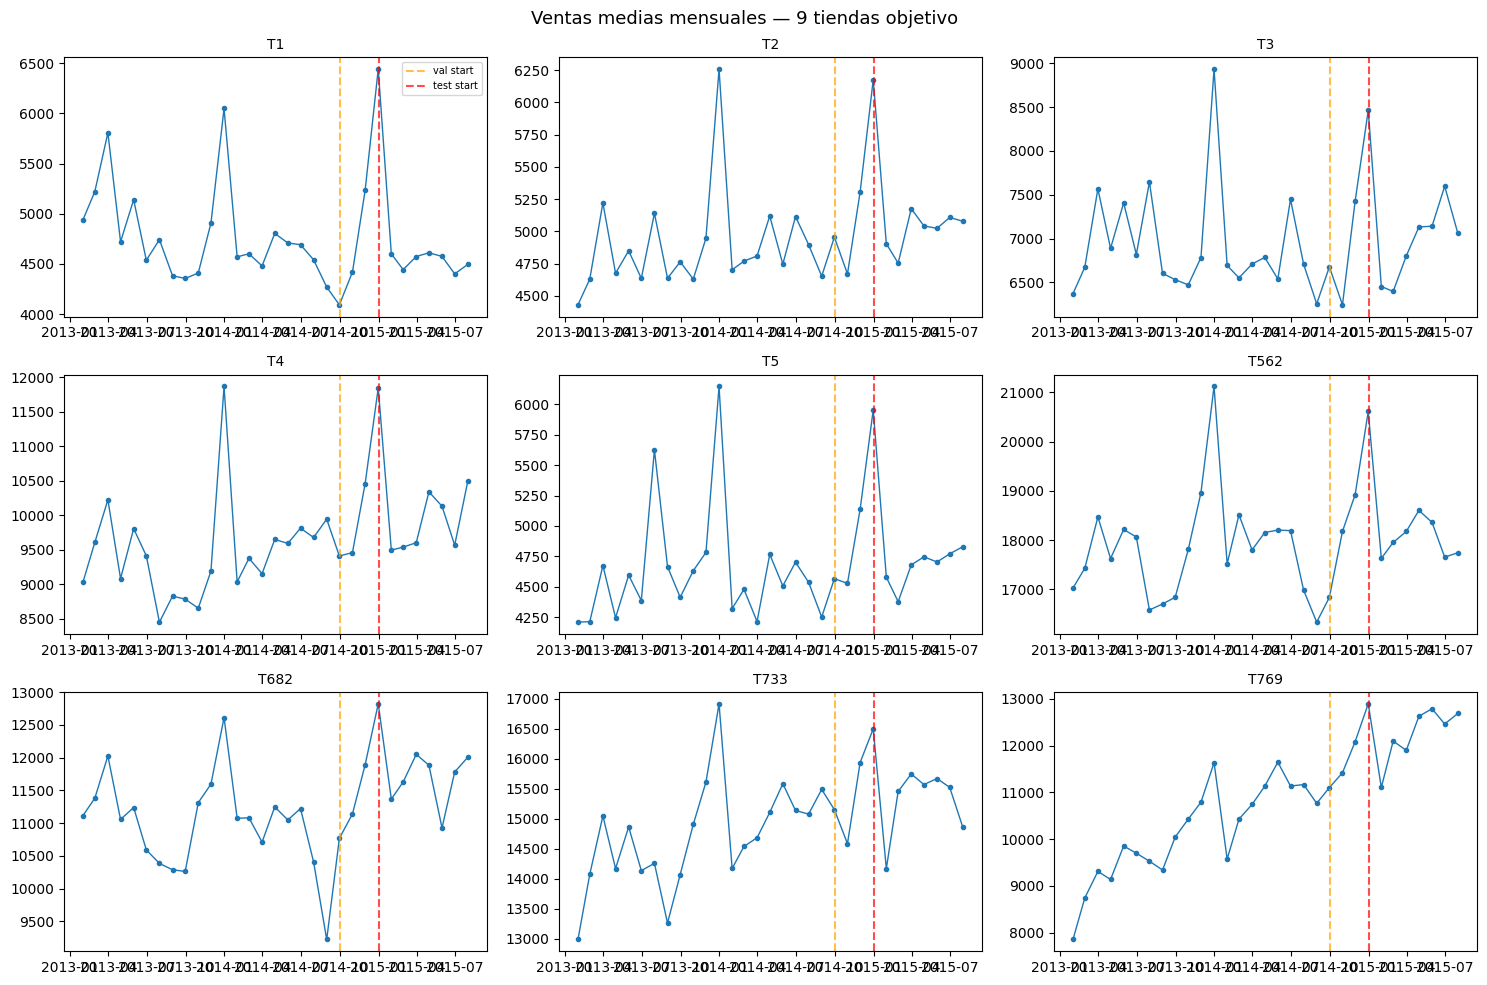

In [53]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, sid in enumerate(ev.TARGET_STORES):
    ax = axes[i]
    g = df[df["Store"] == sid].groupby(pd.Grouper(key="Date", freq="ME"))["Sales"].mean()
    ax.plot(g.index, g.values, marker="o", ms=3, linewidth=1)
    ax.axvline(pd.Timestamp("2014-10-01"), color="orange", linestyle="--", alpha=0.7, label="val start")
    ax.axvline(pd.Timestamp("2015-01-01"), color="red",    linestyle="--", alpha=0.7, label="test start")
    ax.set_title(f"T{sid}", fontsize=10)
    ax.set_xlabel("")
    if i == 0: ax.legend(fontsize=7)
plt.suptitle("Ventas medias mensuales — 9 tiendas objetivo", fontsize=13)
plt.tight_layout()
plt.show()

### Apendice B — Arquitectura del modelo (model.summary)

In [54]:
# Construir modelo solo para ver summary (sin entrenar)
_m = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=len(prep.SEQ_FEATURE_COLS),
    n_static_num_features=len(prep.STATIC_NUM_COLS),
)
_m.summary()
# Total params: ~60,435
# Rama LSTM: seq(30,11)->LSTM(64)->Dropout->Dense(64)
# Rama densa: Emb(Store16)+Emb(Type2)+Emb(Assort2)+Emb(PromoInt2)+Emb(DOW4)+Emb(Month4)+4num -> Dense(64)->Dropout
# Fusion: Concat(64+64)->Dense(128)->Dropout->Dense(1)

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ static (InputLayer) │ (None, 8)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_80 (Lambda)  │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_81 (Lambda)  │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_82 (Lambda)  │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_83 (Lambda)  │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dow (InputLayer)    │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ month (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_Store           │ (None, 1, 16)     │     17,840 │ lambda_80[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_StoreType       │ (None, 1, 2)      │          8 │ lambda_81[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_Assortment      │ (None, 1, 2)      │          6 │ lambda_82[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_PromoInterval   │ (None, 1, 2)      │          8 │ lambda_83[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_dow (Embedding) │ (None, 1, 4)      │         28 │ dow[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_month           │ (None, 1, 4)      │         48 │ month[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq (InputLayer)    │ (None, 30, 11)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_96          │ (None, 16)        │          0 │ emb_Store[0][0]   │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_97          │ (None, 2)         │          0 │ emb_StoreType[0]… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_98          │ (None, 2)         │          0 │ emb_Assortment[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_99          │ (None, 2)         │          0 │ emb_PromoInterva… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_100         │ (None, 4)         │          0 │ emb_dow[0][0]     │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_101         │ (None, 4)         │          0 │ emb_month[0][0] 

 Total params: 60,435 (236.07 KB)

 Trainable params: 60,435 (236.07 KB)

 Non-trainable params: 0 (0.00 B)

### Apendice C — Curvas de entrenamiento (todos los modelos)

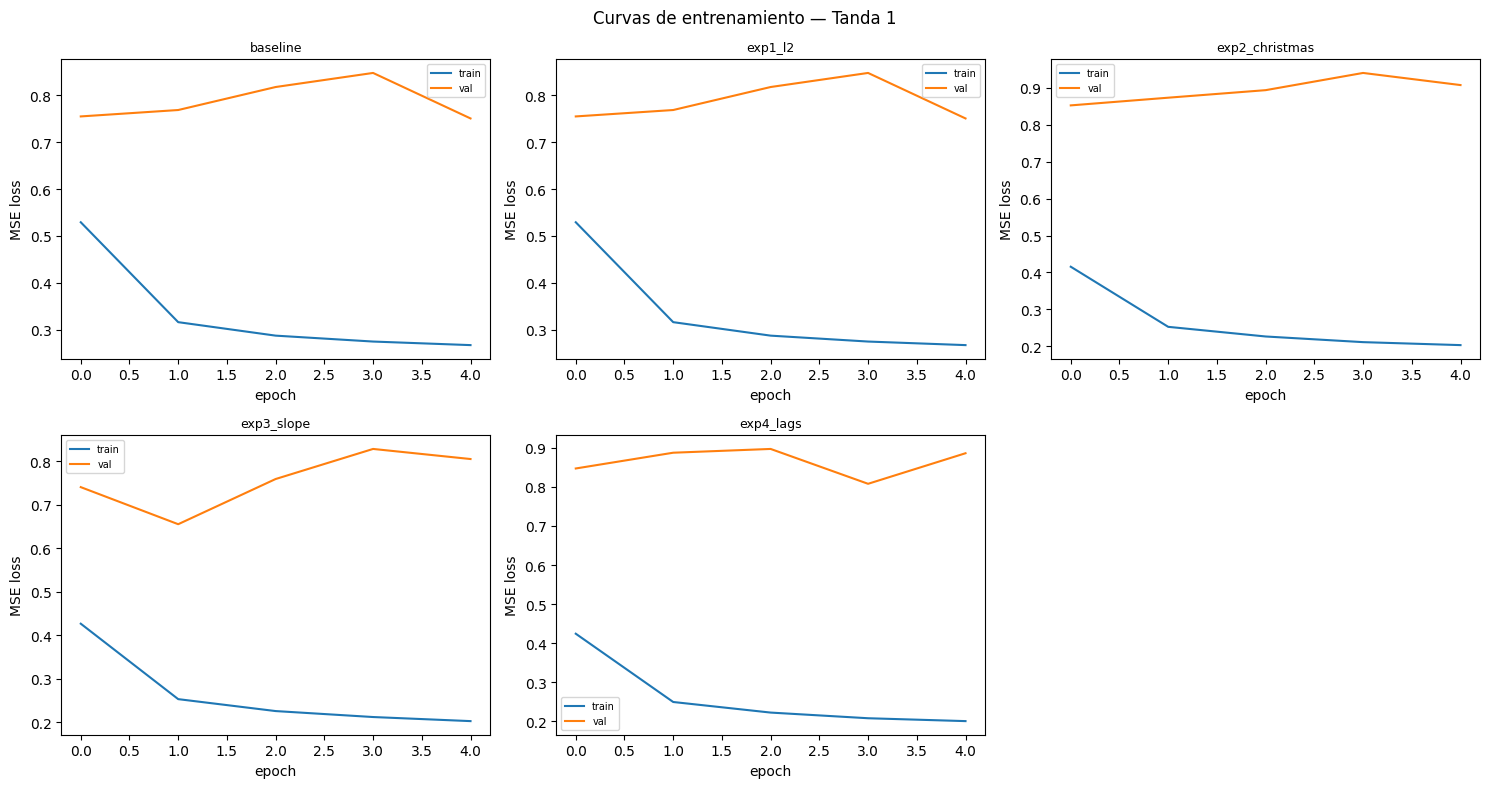

In [55]:
# Agrupar todos los historicos en una figura
histories = {
    "baseline": h_e1,  # reemplazar con el history correcto si se renombra
    "exp1_l2": h_e1,
    "exp2_christmas": h_e2,
    "exp3_slope": h_e3,
    "exp4_lags": h_e4,
}
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, (name, h) in enumerate(histories.items()):
    if i >= len(axes): break
    ax = axes[i]
    ax.plot(h.history["loss"],     label="train")
    ax.plot(h.history["val_loss"], label="val")
    ax.set_title(name, fontsize=9)
    ax.legend(fontsize=7)
    ax.set_xlabel("epoch")
    ax.set_ylabel("MSE loss")
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Curvas de entrenamiento — Tanda 1", fontsize=12)
plt.tight_layout()
plt.show()
# NOTA: sustituir histories dict con h_e5, h_e6 cuando se ejecute Tanda 2

### Apendice D — PCA de embeddings de tienda

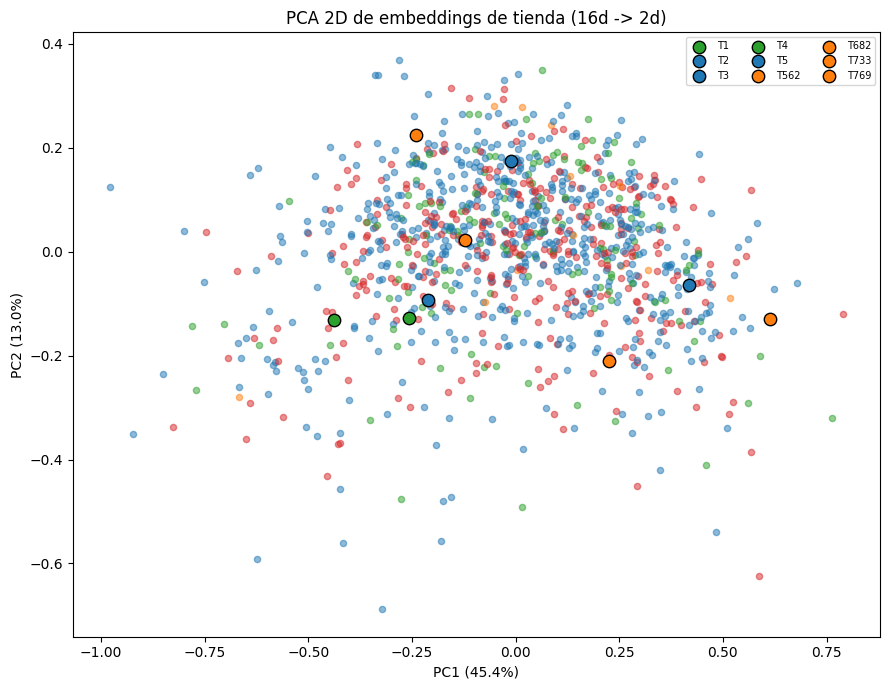

In [57]:
from sklearn.decomposition import PCA

# Usar el mejor modelo disponible (cambiar a model_e5 tras Tanda 2)
best_model = model_e4
emb_layer = best_model.get_layer("emb_Store")
store_weights = emb_layer.get_weights()[0]  # shape (n_stores, 16)
pca = PCA(n_components=2)
coords = pca.fit_transform(store_weights)

# Colorear por tipo de tienda
store_types = df.drop_duplicates("Store").set_index("Store")["StoreType"].to_dict()
colors = {"a":"tab:blue","b":"tab:orange","c":"tab:green","d":"tab:red"}

plt.figure(figsize=(9, 7))
for sid in range(store_weights.shape[0]):
    st = store_types.get(sid+1, "a")
    plt.scatter(coords[sid, 0], coords[sid, 1], c=colors.get(st, "gray"), alpha=0.5, s=20)

# Destacar las 9 tiendas objetivo
for sid in ev.TARGET_STORES:
    idx = sid - 1
    st = store_types.get(sid, "a")
    plt.scatter(coords[idx, 0], coords[idx, 1], c=colors.get(st,"gray"),
                edgecolors="black", s=80, zorder=5, label=f"T{sid}")
plt.title("PCA 2D de embeddings de tienda (16d -> 2d)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(ncol=3, fontsize=7)
plt.tight_layout()
plt.show()